# Text Detection on `LinkNet` using specific functions
- **Author:** Juan Pablo Triana Martinez + Claude Code
- **Date:** 2026-03-24

The following contains all of the training codes necessary in order to perform `binary_text_segmentation` and `pdf_layout_segmentation`.
1. Instantiate a `LinkNet` model for **binary text segmentation** from `src.models` and make sure you can run a pass.
    **NOTE:** Set the height and width sizes to 512, this is a test and empirical evidence showed that downsampling to 512 keeps the text quality; while also performing proper text-detection.
2. Instantiate a `LinkNet` model for **semantic pdf segmentation** from `src.models` and make sure you can run a pass.
    **NOTE:** Set the height and width sizes to 512, this is a test and empirical evidence showed that downsampling to 512 keeps the text quality; while also performing proper text-detection.
3. Import from `src.utils` all necesary function to obtain proper binary and text metrics.
4. We will create a `train_step()` function that will take the following:
    - `model`: take a `torch.nn.Module` model, the `LinkNet` model.
    - `dataloader`: take a `torch.utils.data.Dataloader` to perform batched training.
    - `loss_fn`: take a `torch.nn.Module` loss function to train agains, we will use `DiceLoss` from `src.training` python module.
    - `optimizer`: take a `torch.optim.Optimizer` to assign a specific optimizer.
    - `device`: take a `torch.device` to assign 
4. We will create a `test_step()` function , with the same parameters as `train_step()`, but without `loss_fn`.
5. We will create a `train()` function, that will tale the same parameters as `train_step()`, but also these two:
    - `epochs`: integer of how many total epochs to do.
    - `passed_writer`: take, from `torch.utils.tensorboard`, a `SummaryWriter` to annotate all metrics obtained. 

## 1. Get different instances of `LinkNet` models for binary-text detection

In [1]:
from pathlib import Path
import sys
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict
import os

In [2]:
# Resolve the project root and add it to the module search path
working_path = Path().cwd().parent
sys.path.insert(0, str(working_path))

### 1.1 Let's get the `torch.utils.Dataloaders` for both classification tasks.

In [3]:
from src.data import get_dataloaders_text_detection

In [4]:
data_path = working_path / "data"
subset_dataname = "google_collab_seed_86"

In [5]:
# Set seeds
import random
def set_seeds(seed: int=42):
  """Sets random sets for torch operations.

  Args:
    seed (int, optional): Random seed to set. Defaults to 42.
  """
  # Set the random seed for sampling
  random.seed(seed)

  # Set the seed for general torch operations
  torch.manual_seed(seed)
  # Set the seed for CUDA torch operations (ones that happen on the GPU)
  torch.cuda.manual_seed(seed)

In [6]:
# Set the seeds
set_seeds()

In [22]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

#### 1.1.1 Load `binary-text` masks and inspect a single batch

In [ ]:
BATCH_SIZE = 8
NEW_HEIGHT = 512
NEW_WIDTH = 512

# ============== MANUALLY SETUP IN CASE BREAKS ================ #
#NUM_WORKERS = os.cpu_count()
NUM_WORKERS = 0
#PIN_MEMORY = True
PIN_MEMORY = False
# ============== MANUALLY SETUP IN CASE BREAKS ================ #

# Let's get the binary dataloaders
binary_train_dl, binary_val_dl, binary_test_dl = get_dataloaders_text_detection(
    data_path=data_path,
    dataset_name=subset_dataname,
    mask_type="binary-text",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    new_height=NEW_HEIGHT,
    new_width=NEW_WIDTH,
    transform=None,
)

In [23]:
sample_batch_binary = next(iter(binary_train_dl))

batch_binary_imgs  : torch.Tensor = sample_batch_binary[0]
batch_binary_masks : torch.Tensor = sample_batch_binary[1]
batch_binary_meta  : dict         = sample_batch_binary[2]

print(f"Binary images shape : {batch_binary_imgs.shape}")
print(f"Binary masks  shape : {batch_binary_masks.shape}  "
      f"max={batch_binary_masks.max():.0f}  min={batch_binary_masks.min():.0f}  "
      f"dtype={batch_binary_masks.dtype}")

Binary images shape : torch.Size([8, 3, 512, 512])
Binary masks  shape : torch.Size([8, 1, 512, 512])  max=1  min=0  dtype=torch.float32


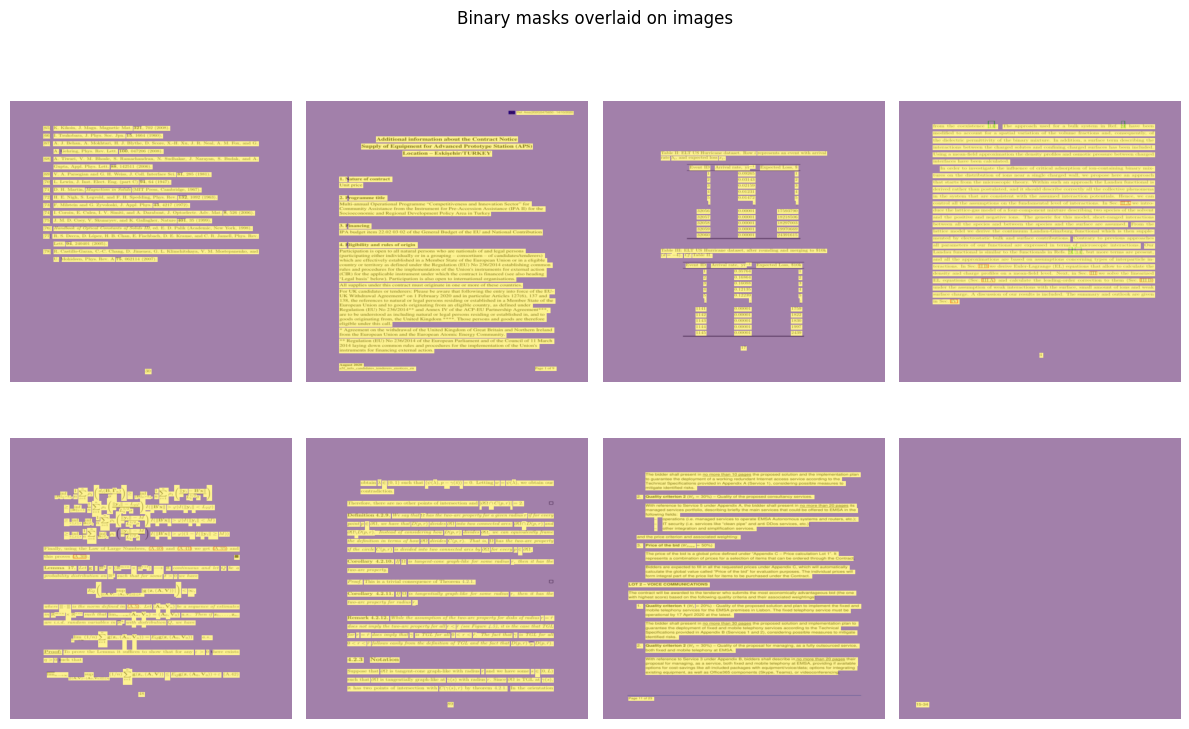

In [24]:
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))
for b in range(batch_binary_imgs.shape[0]):
    ax = axs[b // 4, b % 4]
    ax.imshow(batch_binary_imgs[b].permute(1, 2, 0).cpu())
    ax.imshow(batch_binary_masks[b].permute(1, 2, 0).cpu(), alpha=0.5)
    ax.axis("off")
plt.suptitle("Binary masks overlaid on images")
plt.tight_layout()
plt.show()

#### 1.1.2 Load `semantic-layout` masks and inspect a single batch

In [25]:
semantic_train_dl, semantic_val_dl, semantic_test_dl = get_dataloaders_text_detection(
    data_path=data_path,
    dataset_name=subset_dataname,
    mask_type="semantic-layout",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    new_height=NEW_HEIGHT,
    new_width=NEW_WIDTH,
    transform=None,
)

In [26]:
sample_batch_semantic = next(iter(semantic_train_dl))

batch_semantic_imgs  : torch.Tensor = sample_batch_semantic[0]
batch_semantic_masks : torch.Tensor = sample_batch_semantic[1]
batch_semantic_meta  : dict         = sample_batch_semantic[2]

print(f"Semantic images shape : {batch_semantic_imgs.shape}")
print(f"Semantic masks  shape : {batch_semantic_masks.shape}  "
      f"max={batch_semantic_masks.max()}  min={batch_semantic_masks.min()}  "
      f"dtype={batch_semantic_masks.dtype}")

Semantic images shape : torch.Size([8, 3, 512, 512])
Semantic masks  shape : torch.Size([8, 512, 512])  max=10  min=0  dtype=torch.int64


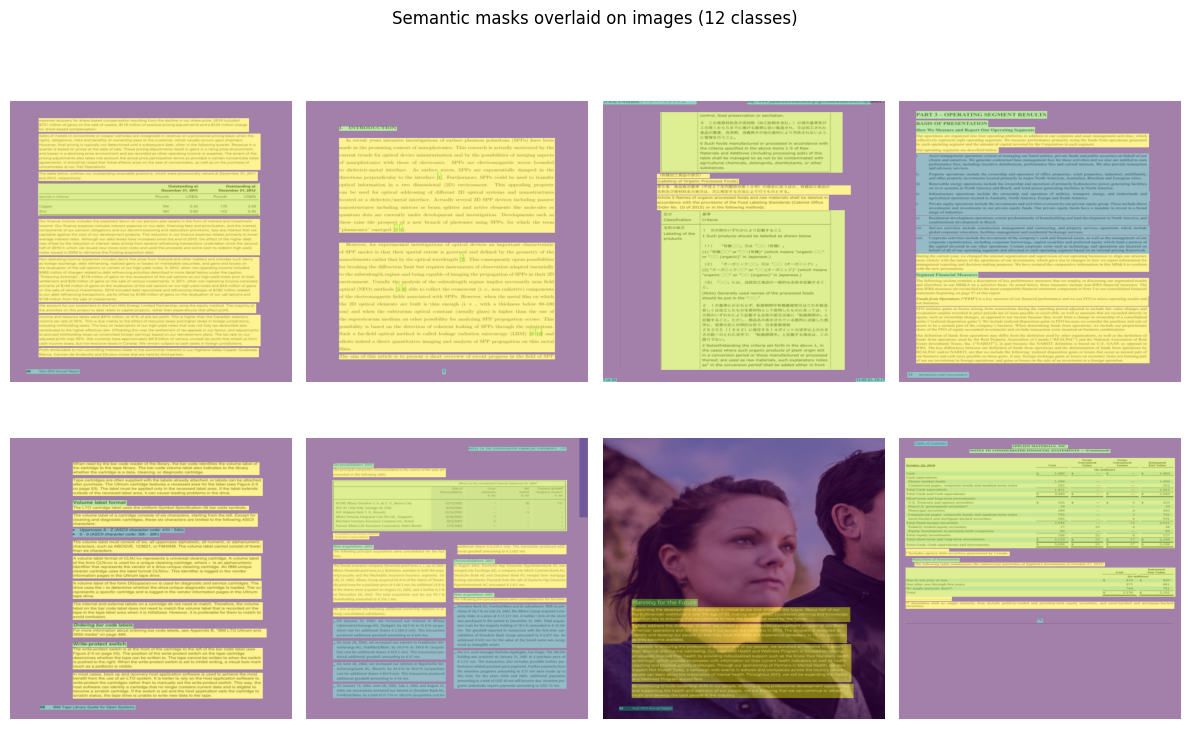

In [27]:
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))
for b in range(batch_semantic_imgs.shape[0]):
    ax = axs[b // 4, b % 4]
    ax.imshow(batch_semantic_imgs[b].permute(1, 2, 0).cpu())
    ax.imshow(batch_semantic_masks[b].cpu(), alpha=0.5)
    ax.axis("off")
plt.suptitle("Semantic masks overlaid on images (12 classes)")
plt.tight_layout()
plt.show()

### 1.2. Instantiate `LinkNet` model for `binary text segmentation`

In [28]:
from src.models import LinknetModel

In [29]:
# Let's instantiate a binary_text_model
binary_text_model = LinknetModel(Cin=3, N = 1).to(device=device)

In [30]:
from torchinfo import summary
summary(model = binary_text_model,
        input_size=(1, 3, 512, 512), # (batch_size, num_channels, height, width) -> (B * 64 * 256 * 256)
        col_names = ["input_size", "output_size", "num_params", "trainable"],
        col_width = 20,
        row_settings = ["var_names"]
        )

Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
LinknetModel (LinknetModel)                   [1, 3, 512, 512]     [1, 1, 512, 512]     --                   True
├─LinknetStem (stem)                          [1, 3, 512, 512]     [1, 64, 128, 128]    --                   True
│    └─Sequential (linknet_stem)              [1, 3, 512, 512]     [1, 64, 128, 128]    --                   True
│    │    └─Conv2d (0)                        [1, 3, 512, 512]     [1, 64, 256, 256]    9,408                True
│    │    └─BatchNorm2d (1)                   [1, 64, 256, 256]    [1, 64, 256, 256]    128                  True
│    │    └─ReLU (2)                          [1, 64, 256, 256]    [1, 64, 256, 256]    --                   --
│    │    └─MaxPool2d (3)                     [1, 64, 256, 256]    [1, 64, 128, 128]    --                   --
├─LinknetEncoderBlock (encoder_block_1)       [1, 64, 128, 128]    [1, 64, 64, 64]     

## 2. Get different instances of `LinkNet` models for semantic-pdf-layout segmentation

In [32]:
from src.utils import MetadataRetriever

# Let's get the metadata supercategories
metadata_retriever = MetadataRetriever(
    data_path=data_path,
    dataset_name=subset_dataname,
    split_analyze="test")

supercategories_classes = metadata_retriever.get_metadata_supercategories()
CLASSES = len(supercategories_classes) + 1 # Adding one for the background
CLASSES

12

In [33]:
# Let's instantiate a binary_text_model
segmentation_pdf_model = LinknetModel(Cin=3, N = CLASSES).to(device=device)

In [34]:
from torchinfo import summary
summary(model = segmentation_pdf_model,
        input_size=(1, 3, 512, 512), # (batch_size, num_channels, height, width) -> (B * 64 * 256 * 256)
        col_names = ["input_size", "output_size", "num_params", "trainable"],
        col_width = 20,
        row_settings = ["var_names"]
        )

Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
LinknetModel (LinknetModel)                   [1, 3, 512, 512]     [1, 12, 512, 512]    --                   True
├─LinknetStem (stem)                          [1, 3, 512, 512]     [1, 64, 128, 128]    --                   True
│    └─Sequential (linknet_stem)              [1, 3, 512, 512]     [1, 64, 128, 128]    --                   True
│    │    └─Conv2d (0)                        [1, 3, 512, 512]     [1, 64, 256, 256]    9,408                True
│    │    └─BatchNorm2d (1)                   [1, 64, 256, 256]    [1, 64, 256, 256]    128                  True
│    │    └─ReLU (2)                          [1, 64, 256, 256]    [1, 64, 256, 256]    --                   --
│    │    └─MaxPool2d (3)                     [1, 64, 256, 256]    [1, 64, 128, 128]    --                   --
├─LinknetEncoderBlock (encoder_block_1)       [1, 64, 128, 128]    [1, 64, 64, 64]     

## 3. Import from `src.utils ` all necessary functions to obtain pixel-region metrics

In [35]:
from src.utils import get_binary_metrics, get_semantic_metrics, get_region_metrics

## 4. Let's create the `train_step()` function
This will be key to do! be careful with little details.

In [36]:
'''
This trains a PyTorch linknet semantic segmentation model,
in both the binary and multiclass segmentation settings
code.
'''
import torch
from typing import Tuple, Dict
from collections import defaultdict

def train_step(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               device:torch.device,
               binary:bool = True,
               ignore_background:bool = True,
               reduction:str = "macro") -> Tuple[float, Dict[str, float]]:
    """Trains a PyTorch model for a single epoch.

    Turns a target PyTorch model to training mode and then
    runs through all of the required training steps (forward
    pass, loss calculation, optimizer step).

    Args:
    model: A PyTorch model to be trained.
    dataloader: A DataLoader instance for the model to be trained on.
    loss_fn: A PyTorch loss function to minimize.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    device: A target device to compute on (e.g. "cuda" or "cpu").
    binary: Boolean that determines wether is binary segmentation, or not.
    ignore_background: Boolean falg that determines in semantic segmentation, to ignore
    background class 0 or not.
    reduction: string that either is macro or micro, for semantic kind of pixel metrics
    calculation.

    Returns:
    A tuple of training loss and training accuracy metrics.
    In the form (train_loss, train_accuracy). For example:

    (0.1112, 0.8743)

    """

    assert reduction in ["macro", "micro"], "Reduction must be either 'macro' or 'micro'."

    model.train()

    train_loss = 0.0
    total_metrics: Dict[str, float] = defaultdict(float)
    num_batches = 0

    for batch, (X_imgs, X_masks, X_metadata) in enumerate(dataloader):

        # Move data to device
        X_imgs = X_imgs.to(device)
        X_masks = X_masks.to(device)

        # Forward pass
        X_logits = model(X_imgs)

        # Compute loss
        loss = loss_fn(X_logits, X_masks)
        train_loss += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metric computation (no gradient tracking)
        with torch.no_grad():

            if binary:
                pixel_metrics = get_binary_metrics(X_logits, X_masks)
                region_metrics = get_region_metrics(
                    X_logits, X_masks, is_binary=True
                )
            else:
                pixel_metrics = get_semantic_metrics(
                    logits=X_logits,
                    targets=X_masks,
                    num_classes=X_logits.shape[1],
                    ignore_background=ignore_background,
                    reduction=reduction
                )
                region_metrics = get_region_metrics(
                    X_logits, X_masks, is_binary=False
                )

            # Accumulate pixel-level metrics
            for k, v in pixel_metrics.items():
                total_metrics[k] += float(v)

            # Accumulate region-level metrics (averaged per batch)
            for k, v in region_metrics.items():
                total_metrics[k] += float(v.mean())

        num_batches += 1

    # Compute averages
    avg_loss = train_loss / num_batches
    avg_metrics = {k: v / num_batches for k, v in total_metrics.items()}

    return avg_loss, avg_metrics

## 5. Let's create `test_step()` function, with same parameters as `train_step()`, but without loss_fn

In [37]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device,
              binary:bool = True,
              ignore_background:bool = True,
              reduction:str = "macro") -> Tuple[float, Dict[str, float]]:
    """Tests a PyTorch model for a single epoch.

    Turns a target PyTorch model to "eval" mode and then performs
    a forward pass on a testing dataset.

    Args:
    model: A PyTorch model to be tested.
    dataloader: A DataLoader instance for the model to be tested on.
    loss_fn: A PyTorch loss function to calculate loss on the test data.
    device: A target device to compute on (e.g. "cuda" or "cpu").
    binary: Boolean that determines wether is binary segmentation, or not.
    ignore_background: Boolean falg that determines in semantic segmentation, to ignore
    background class 0 or not.
    reduction: string that either is macro or micro, for semantic kind of pixel metrics
    calculation.

    Returns:
    A tuple of testing loss and testing accuracy metrics.
    In the form (test_loss, test_accuracy). For example:

    (0.0223, 0.8985)
    """

    assert reduction in ["macro", "micro"], "Reduction must be either 'macro' or 'micro'."

    # Put the model in eval mode
    model.eval()

    # Setup all values for loss and total_metrics
    test_loss = 0.0
    total_metrics: Dict[str, float] = defaultdict(float)
    num_batches = 0

    # Turn on the inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X_imgs, X_masks, X_metadata) in enumerate(dataloader):

            # Move data to device
            X_imgs = X_imgs.to(device)
            X_masks = X_masks.to(device)

            # Forward pass
            X_logits = model(X_imgs)

            #2. Calculate and accumulate the loss
            loss = loss_fn(X_logits, X_masks)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            if binary:
                pixel_metrics = get_binary_metrics(X_logits, X_masks)
                region_metrics = get_region_metrics(
                    X_logits, X_masks, is_binary=True
                )
            else:
                pixel_metrics = get_semantic_metrics(
                    logits=X_logits,
                    targets=X_masks,
                    num_classes=X_logits.shape[1],
                    ignore_background=ignore_background,
                    reduction=reduction
                )
                region_metrics = get_region_metrics(
                    X_logits, X_masks, is_binary=False
                )

            # Accumulate pixel-level metrics
            for k, v in pixel_metrics.items():
                total_metrics[k] += float(v)

            # Accumulate region-level metrics (averaged per batch)
            for k, v in region_metrics.items():
                total_metrics[k] += float(v.mean())
            
            # Add the number of batches properly
            num_batches += 1

    # Compute averages
    avg_loss = test_loss / num_batches
    avg_metrics = {k: v / num_batches for k, v in total_metrics.items()}

    return avg_loss, avg_metrics

## 6. Create the `train()` function that will be key to train both the `binary-text` and `semantic-pdf` models.

In [ ]:
from tqdm import tqdm
from typing import Dict, List
from torch.utils.tensorboard import SummaryWriter

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          simulate_batch_size:int,
          simulate_new_channels:int,
          simulate_new_height:int,
          simulate_new_width:int,
          epochs: int,
          device: torch.device,
          passed_writer: SummaryWriter,
          binary:bool = True,
          ignore_background:bool = True,
          reduction:str = "macro",
          ) -> Dict[str, List]:

    """Trains and tests a PyTorch model.

    Passes a target PyTorch models through train_step() and test_step()
    functions for a number of epochs, training and testing the model
    in the same epoch loop.

    Calculates, prints and stores evaluation metrics throughout.

    Args:
    model: A PyTorch model to be trained and tested.
    train_dataloader: A DataLoader instance for the model to be trained on.
    test_dataloader: A DataLoader instance for the model to be tested on.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    loss_fn: A PyTorch loss function to calculate loss on both datasets.
    simulate_batch_size: An integer used to create a graph model with tensorboard, recommended: 8.
    simulate_new_channels: An integer simulating new number of channels in graph model with tensorboard, 1 if binary or C classes if semantic.
    simulate_new_height: An integer used to simulate new width when images were transformed in the graph model with tensorboard, make sure is the same used with dataloaders.
    simulate_new_width: An integer used to simulate new height when images were transformed in the graph model with tensorboard, make sure is the same used with dataloaders.
    epochs: An integer indicating how many epochs to train for.
    device: A target device to compute on (e.g. "cuda" or "cpu").
    binary: Boolean that determines wether is binary segmentation, or not.
    ignore_background: Boolean falg that determines in semantic segmentation, to ignore
    background class 0 or not.
    reduction: string that either is macro or micro, for semantic kind of pixel metrics
    calculation.

    Returns:
    A dictionary of training and testing loss as well as pixel and region
    metrics for text detection. Each metric has a value in a list for
    each epoch.
    In the form: {train_loss: [...],
              train_acc: [...],
              metric_1_pixel: [...],
              metric_1_region: [...]
              ...}
    For example if training for epochs=2:
             {train_loss: [2.0616, 1.0537],
              train_acc: [0.3945, 0.3945],
              metric_1_pixel: [1.2641, 1.5706],
              metric_2_pixel: [0.3400, 0.2973]}
    """
    # Create empty results dictionary
    results: Dict[str, List] = defaultdict(list)

    # Make sure model on target device
    model.to(device)

    # Add model graph once before training starts
    if passed_writer:
        passed_writer.add_graph(
            model=model,
            input_to_model=torch.randn(simulate_batch_size, simulate_new_channels, simulate_new_height, simulate_new_width).to(device))

    # Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_metrics = train_step(model=model,
               dataloader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               device=device,
               binary=binary,
               ignore_background=ignore_background,
               reduction=reduction)

        # Assign train metrics properly
        results["train_loss"].append(train_loss)
        for k, v in train_metrics.items():
            k_new = k + "_train"
            results[k_new].append(v)

        test_loss, test_metrics = test_step(model=model,
              dataloader=test_dataloader,
              loss_fn=loss_fn,
              device=device,
              binary=binary,
              ignore_background=ignore_background,
              reduction=reduction)

        # Assign test metrics properly
        results["test_loss"].append(test_loss)
        for k, v in test_metrics.items():
            k_new = k + "_test"
            results[k_new].append(v)

        # Print out what's happening
        print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"iou_pixel_train: {results['iou_pixel_train'][-1]:.4f} | "
          f"dice_pixel_train: {results['dice_pixel_train'][-1]:.4f} | "
          f"IoU_region_train: {results['IoU_region_train'][-1]:.4f} | "
          f"DsC_region_train: {results['DsC_region_train'][-1]:.4f} | "
        )

        print(
          f"Epoch: {epoch+1} | "
          f"test_loss: {test_loss:.4f} | "
          f"iou_pixel_test: {results['iou_pixel_test'][-1]:.4f} | "
          f"dice_pixel_test: {results['dice_pixel_test'][-1]:.4f} | "
          f"IoU_region_test: {results['IoU_region_test'][-1]:.4f} | "
          f"DsC_region_test: {results['DsC_region_test'][-1]:.4f} | "
        )

        ### New: Experiment tracking ###
        if passed_writer:
            # Log loss
            passed_writer.add_scalars(
                main_tag="Loss",
                tag_scalar_dict={"train_loss": train_loss, "test_loss": test_loss},
                global_step=epoch)

            # Log each metric with its actual train/test values
            all_metrics_keys = train_metrics.keys()
            for k in all_metrics_keys:
                passed_writer.add_scalars(
                    main_tag=k,
                    tag_scalar_dict={"train": train_metrics[k], "test": test_metrics[k]},
                    global_step=epoch)

    # Close writer once after all epochs
    if passed_writer:
        passed_writer.close()
    ### End New ###

    # Return the filled results at the end of the epochs
    return results

In [39]:
from torch.utils.tensorboard import SummaryWriter
def create_writer(experiment_name: str,
                  model_name: str,
                  extra: str = None):
  """
  Creates a torch.utils.tensorboard.writer.SummaryWriter() instance tracking into a
  specific directory
  """

  from datetime import datetime
  import os

  # Get timestamp of current date in reverse order
  timestamp = datetime.now().strftime("%Y-%m-%d")

  if extra:
    # Creaate log directory path
    log_dir = os.path.join("runs", timestamp, experiment_name, model_name, extra)
  else:
    log_dir = os.path.join("runs", timestamp, experiment_name, model_name)
  print(f"[INFO] Created SummaryWriter saving to {log_dir}")
  return SummaryWriter(log_dir=log_dir)

## 7. Create `add_hparams_to_writer()` helper to log hyperparameters into TensorBoard

In [ ]:
def add_hparams_to_writer(
    writer: SummaryWriter,
    batch_size: int,
    new_height: int,
    new_width: int,
    num_workers: int,
    pin_memory: bool,
    results: Dict[str, List],
) -> None:
    """
    Logs hyperparameters and final-epoch metrics into TensorBoard's HParams tab.

    Opens a new SummaryWriter pointing to the same log_dir as the passed writer
    (which was already closed by train()), records all hparams and the last value
    of every key in results, then closes.

    Args:
        writer:      The SummaryWriter used during training (log_dir is read from it).
        batch_size:  Batch size used by the dataloaders.
        new_height:  Image height passed to the dataloaders.
        new_width:   Image width passed to the dataloaders.
        num_workers: Number of dataloader workers.
        pin_memory:  Whether pinned memory was enabled.
        results:     The dict returned by train() — keys map to lists of per-epoch values.
    """
    hparam_dict = {
        "batch_size": batch_size,
        "new_height": new_height,
        "new_width": new_width,
        "num_workers": num_workers,
        "pin_memory": pin_memory,
    }

    # Take the final epoch value for every tracked metric
    metric_dict = {f"final_{k}": float(v[-1]) for k, v in results.items()}

    # train() already closed the writer; reopen at the same log_dir to write hparams
    hparam_writer = SummaryWriter(log_dir=writer.log_dir)
    hparam_writer.add_hparams(hparam_dict=hparam_dict, metric_dict=metric_dict)
    hparam_writer.close()
    print(f"[INFO] Hyperparameters logged to {writer.log_dir}")

## 8. Train `binary_text_model` using `DiceLoss` and log results

In [ ]:
from src.training import DiceLoss

EPOCHS = 5
LR = 1e-3

# Loss, optimizer, writer
binary_loss_fn = DiceLoss(smooth=1e-7, ignore_background=False)
binary_optimizer = torch.optim.Adam(binary_text_model.parameters(), lr=LR)
binary_writer = create_writer(
    experiment_name="DocLayNet_text_detection",
    model_name="LinkNet",
    extra="binary"
)

# Train
binary_results = train(
    model=binary_text_model,
    train_dataloader=binary_train_dl,
    test_dataloader=binary_test_dl,
    optimizer=binary_optimizer,
    loss_fn=binary_loss_fn,
    simulate_batch_size=BATCH_SIZE,
    simulate_new_channels=1,
    simulate_new_height=NEW_HEIGHT,
    simulate_new_width=NEW_WIDTH,
    epochs=EPOCHS,
    device=device,
    passed_writer=binary_writer,
    binary=True,
    ignore_background=False,
    reduction="macro"
)

# Log hyperparameters
add_hparams_to_writer(
    writer=binary_writer,
    batch_size=BATCH_SIZE,
    new_height=NEW_HEIGHT,
    new_width=NEW_WIDTH,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    results=binary_results
)

## 9. Train `segmentation_pdf_model` using `DiceLoss` and log results

In [ ]:
# Loss, optimizer, writer
semantic_loss_fn = DiceLoss(smooth=1e-7, ignore_background=True)
semantic_optimizer = torch.optim.Adam(segmentation_pdf_model.parameters(), lr=LR)
semantic_writer = create_writer(
    experiment_name="DocLayNet_text_detection",
    model_name="LinkNet",
    extra="semantic"
)

# Train
semantic_results = train(
    model=segmentation_pdf_model,
    train_dataloader=semantic_train_dl,
    test_dataloader=semantic_test_dl,
    optimizer=semantic_optimizer,
    loss_fn=semantic_loss_fn,
    simulate_batch_size=BATCH_SIZE,
    simulate_new_channels=CLASSES,
    simulate_new_height=NEW_HEIGHT,
    simulate_new_width=NEW_WIDTH,
    epochs=EPOCHS,
    device=device,
    passed_writer=semantic_writer,
    binary=False,
    ignore_background=True,
    reduction="macro"
)

# Log hyperparameters
add_hparams_to_writer(
    writer=semantic_writer,
    batch_size=BATCH_SIZE,
    new_height=NEW_HEIGHT,
    new_width=NEW_WIDTH,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    results=semantic_results
)